In [4]:
"""
KaggleのOnline Shoppers Purchasing Intention Dataset は、ECサイト上でのユーザー行動ログをもとに「購入するかどうか」を予測する。
"""
#ライブラリをインポート
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
#データ(oneline_shippers.csv)読み込み
df = pd.read_csv("sample_data/online_shoppers.csv")

In [12]:
# 読み込んだデータを確認
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28176 entries, 0 to 28175
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           28176 non-null  int64  
 1   Administrative_Duration  28176 non-null  float64
 2   Informational            28176 non-null  int64  
 3   Informational_Duration   28176 non-null  float64
 4   ProductRelated           28176 non-null  int64  
 5   ProductRelated_Duration  28176 non-null  float64
 6   BounceRates              28176 non-null  float64
 7   ExitRates                28176 non-null  float64
 8   PageValues               28176 non-null  float64
 9   SpecialDay               28175 non-null  float64
 10  OperatingSystems         28175 non-null  float64
 11  Browser                  28175 non-null  float64
 12  Region                   28175 non-null  float64
 13  TrafficType              28175 non-null  float64
 14  Month                 

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,28176.000000,28176.000000,28176.000000,28176.000000,28176.000000,28176.000000,28176.000000,28176.000000,28176.000000,28175.000000,28175.000000,28175.000000,28175.000000,28175.000000
mean,2.751597,117.829420,0.785669,74.466383,37.652257,1500.716603,0.031490,0.047323,8.775035,0.111436,2.161668,2.559290,3.389033,4.574091
std,2.687025,130.390814,0.955192,93.688658,36.413583,1517.337457,0.036883,0.042075,15.809776,0.138422,0.882309,1.449717,2.045160,3.272427
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.011174,0.000000,0.000000,2.000000,1.000000,2.000000,1.000000
50%,2.000000,78.673132,0.000000,34.388137,31.000000,1171.713759,0.017350,0.038399,2.987098,0.054539,2.000000,2.000000,3.000000,4.000000
75%,4.000000,198.010442,1.000000,127.730054,61.000000,2453.719604,0.053407,0.074614,10.560563,0.187787,3.000000,4.000000,5.000000,7.000000
max,16.000000,864.716069,7.000000,714.829657,244.000000,9831.889961,0.200000,0.200000,151.059246,0.867754,6.000000,9.000000,9.000000,20.000000


In [13]:
# 欠損確認
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,1


In [15]:
#欠損処理：欠損箇所を削除した。
df = df.dropna(subset=['Revenue'])
df['Revenue'] = df['Revenue'].astype(int)

In [16]:
#欠損処理後の再確認
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


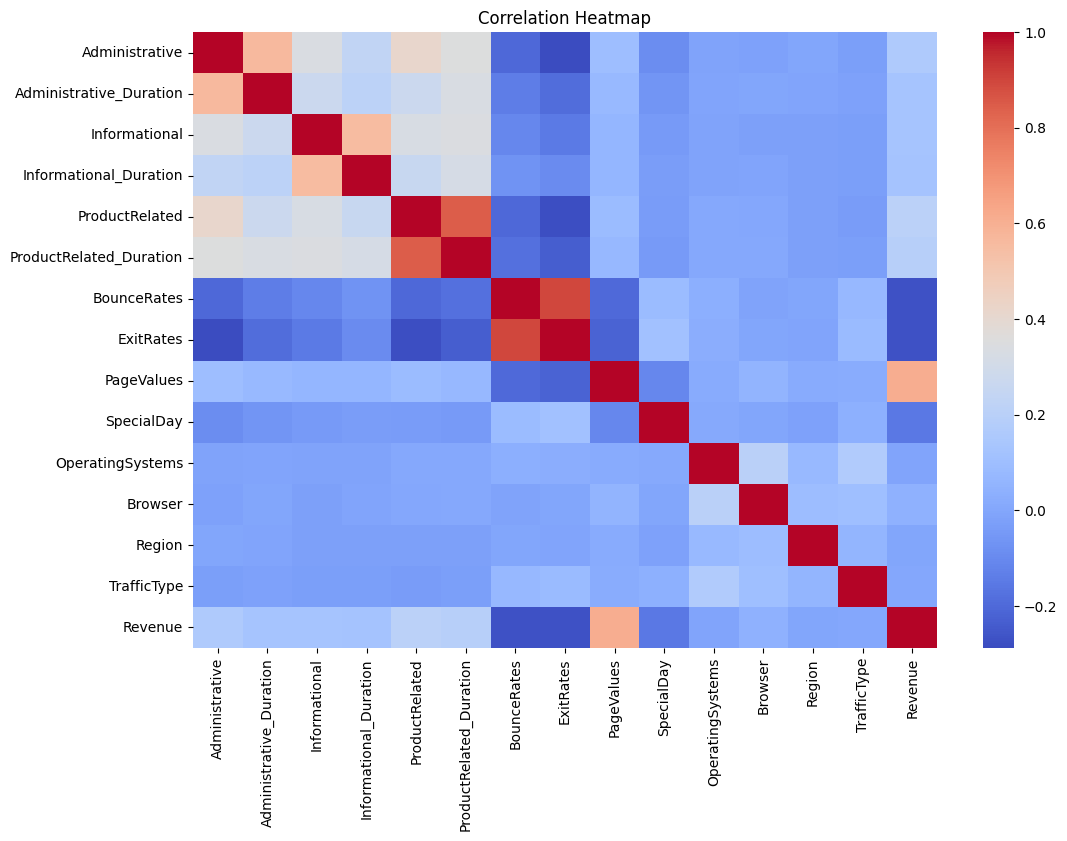

In [17]:
#データセットの可視化：　まずは相関係数ヒートマップで全体を確認する
# Revenueを数値化
df['Revenue'] = df['Revenue'].astype(int)

# 相関行列
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
#Revenueとの相関だけ抜き出す
corr_target = corr['Revenue'].sort_values(ascending=False)
print(corr_target)

Revenue                    1.000000
PageValues                 0.607864
ProductRelated             0.208543
ProductRelated_Duration    0.194152
Administrative             0.159719
Informational              0.127064
Administrative_Duration    0.125787
Informational_Duration     0.121671
Browser                    0.039774
TrafficType                0.002022
Region                    -0.005104
OperatingSystems          -0.007127
SpecialDay                -0.154023
ExitRates                 -0.272743
BounceRates               -0.273005
Name: Revenue, dtype: float64


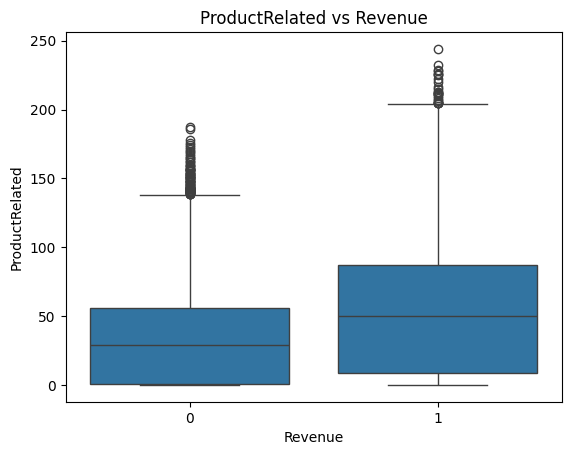

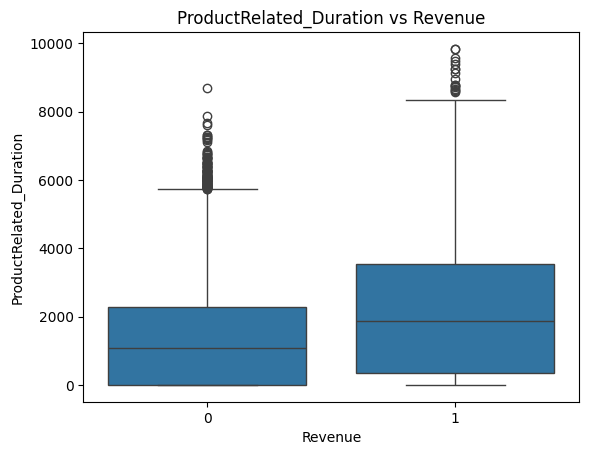

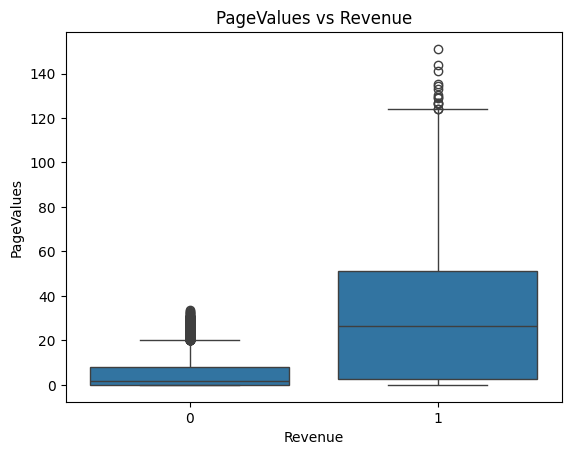

In [19]:
#数値データ：箱ひげ図（分布比較）
num_cols = ['ProductRelated', 'ProductRelated_Duration', 'PageValues']

for col in num_cols:
    plt.figure()
    sns.boxplot(x='Revenue', y=col, data=df)
    plt.title(f"{col} vs Revenue")
    plt.show()

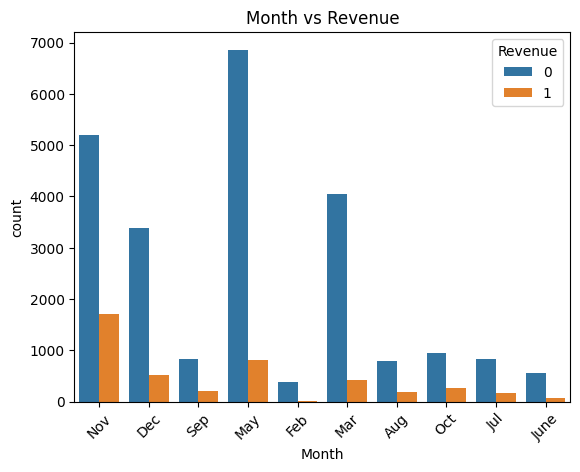

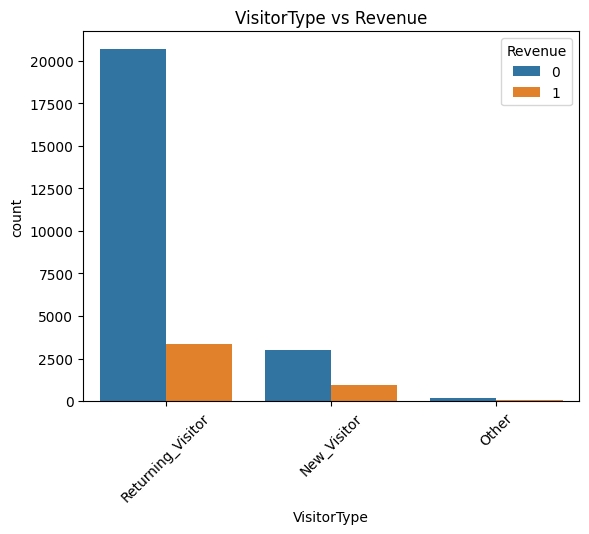

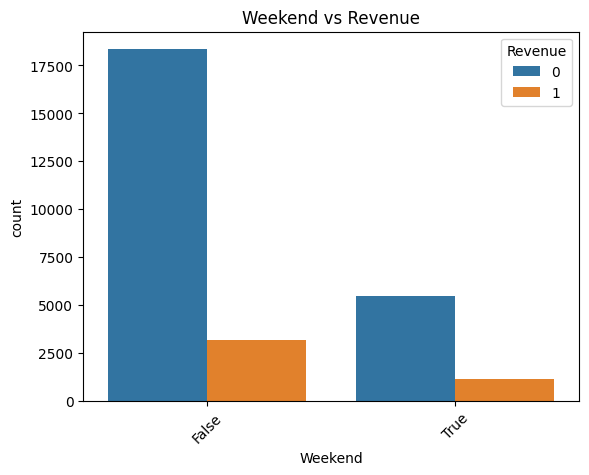

In [20]:
#カテゴリデータ：棒グラフ
cat_cols = ['Month', 'VisitorType', 'Weekend']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='Revenue', data=df)
    plt.title(f"{col} vs Revenue")
    plt.xticks(rotation=45)
    plt.show()

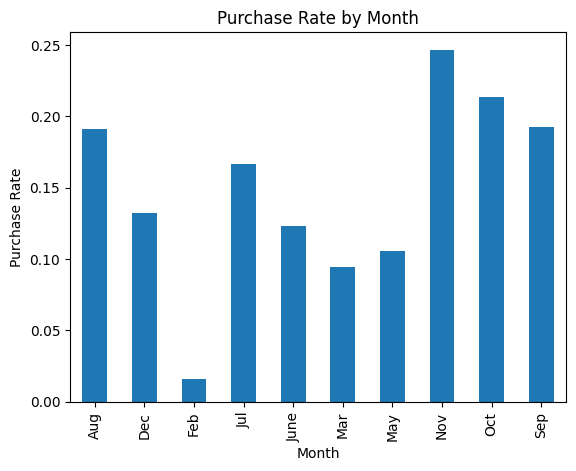

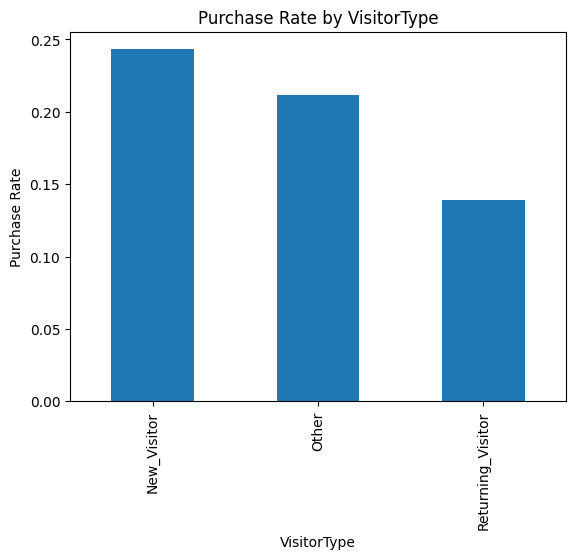

In [21]:
#購入率で可視化
for col in ['Month', 'VisitorType']:
    purchase_rate = df.groupby(col)['Revenue'].mean()

    purchase_rate.plot(kind='bar')
    plt.title(f"Purchase Rate by {col}")
    plt.ylabel("Purchase Rate")
    plt.show()

In [22]:
#分析のためにライブラリをインポート
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [23]:
#分析前の前処理
# カテゴリ変数をエンコード
categorical_cols = ['Month', 'VisitorType', 'Weekend']

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# ターゲット
df['Revenue'] = df['Revenue'].astype(int)

In [24]:
#データ分割
X = df.drop('Revenue', axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
#モデル：過学習対策
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

"""
実行後
RandomForestClassifier(class_weight='balanced', max_depth=7, min_samples_leaf=5,
                       min_samples_split=10, n_estimators=200, random_state=42)
"""

RandomForestClassifier(class_weight='balanced', max_depth=7, min_samples_leaf=5,
                       min_samples_split=10, n_estimators=200, random_state=42)

In [26]:
#分析評価
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9054125998225377
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      4781
           1       0.64      0.84      0.73       854

    accuracy                           0.91      5635
   macro avg       0.81      0.88      0.84      5635
weighted avg       0.92      0.91      0.91      5635



In [ ]:
"""
評価結果から・・・
0=購入しない
1=購入する
「購入する」のPrecisionが0.64のため購入づると予測した64%が実際に購入すると考えられる。但し、36%は予測が外れた。
「購入する」のrecallが0.84から実際に買う人の 84%は見つけられている。
"""
